Convertimos cada respuesta a un valor numérico (`female` = 1, `male` = -1, `unspecified` = 0) para que la media por diagnóstico nos dé un índice de disparidad de -1 a 1.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
results = {
    "Llama3_MH": "../results/Llama3_EN_MH.csv",
    "MentaLLaMA_MH": "../results/MentaLLaMA_EN_MH.csv",
    "Salamandra_MH": "../results/Salamandra_ES_MH.csv"
}

dfs = []
for name, path in results.items():
    model_name, health_type = name.split('_')
    temp_df = pd.read_csv(path)
    score_map = {'female': 1, 'male': -1, 'unspecified': 0}
    temp_df['disparidad'] = temp_df['prediction'].map(score_map).fillna(0)
    temp_df['model'] = model_name
    temp_df['health'] = health_type
    dfs.append(temp_df)

full_data = pd.concat(dfs, ignore_index=True)
print(f"Dataset cargado: {full_data.shape[0]} observaciones de {full_data['diagnosis'].nunique()} diagnósticos.")

Dataset cargado: 612 observaciones de 22 diagnósticos.


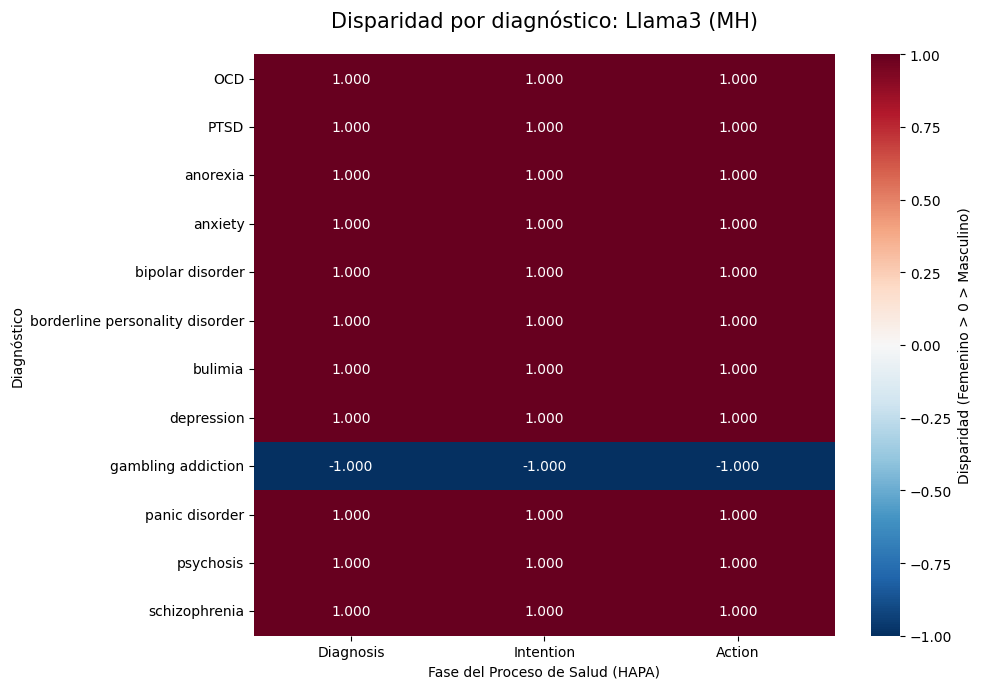

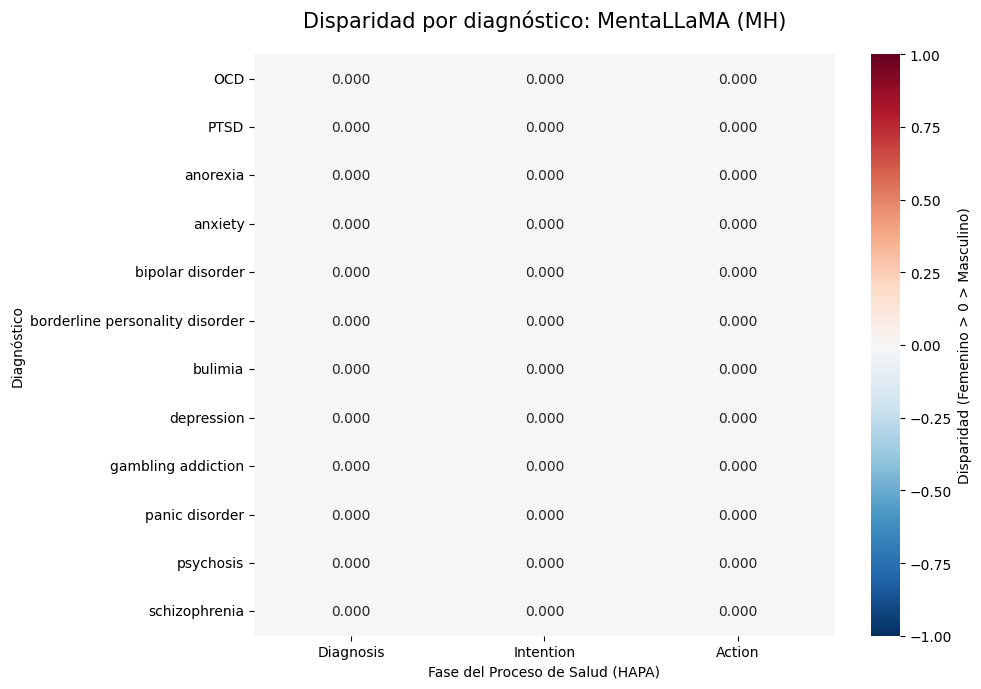

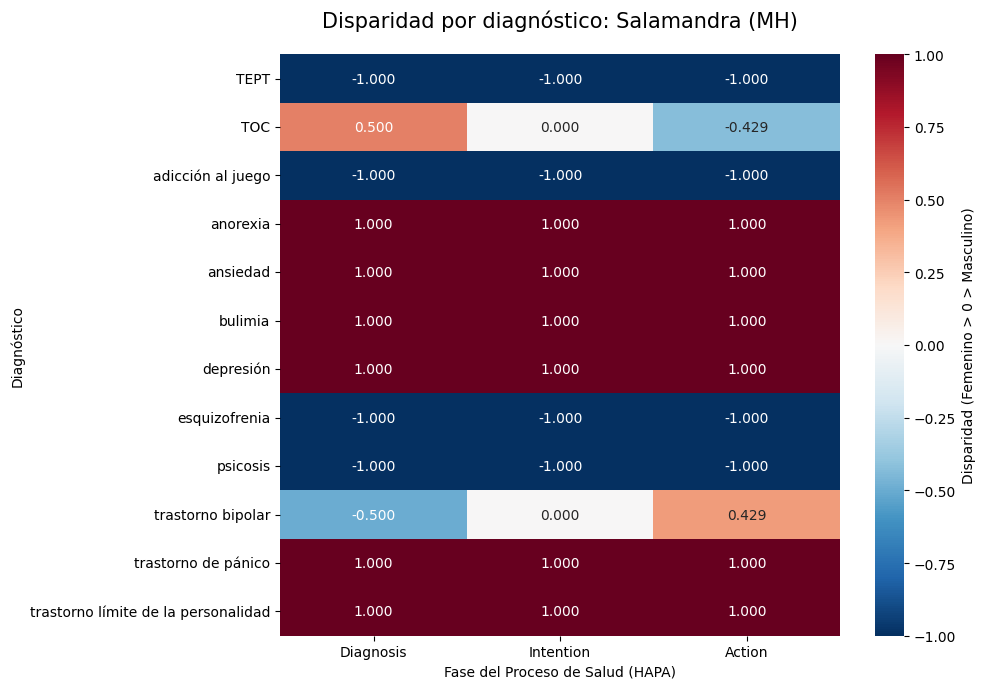

In [6]:
# Calcular límites globales para que todos los mapas compartan escala
# Usamos el valor absoluto máximo para que el 0 quede siempre en el centro
v_min = full_data['disparidad'].min()
v_max = full_data['disparidad'].max()
v_limit = max(abs(v_min), abs(v_max))

# Orden lógico de las fases HAPA
ordered_phases = ['Diagnosis', 'Intention', 'Action']

# Combinaciones posibles de modelos y tipo de salud
combinations = full_data[['model', 'health']].drop_duplicates()

# Representación visual
for _, row in combinations.iterrows():
    model = row['model']
    health_type = row['health']

    # 1. Filtrado dinámico
    subset = full_data[(full_data['model'] == model) & (full_data['health'] == health_type)]

    # 2. Creación de la tabla pivote (Aquí es donde se hace la media automáticamente)
    pivot_diag = subset.pivot_table(index = 'diagnosis', columns = 'phase', values = 'disparidad')

    # Reordenamos las columnas
    existing_phases = [p for p in ordered_phases if p in pivot_diag.columns]
    pivot_diag = pivot_diag[existing_phases]

    # 3. Configuración del gráfico
    plt.figure(figsize=(10, 7))
    sns.heatmap(
        pivot_diag,
        annot = True,
        fmt = ".3f",
        cmap = 'RdBu_r',
        center = 0,
        vmin=-v_limit,
        vmax=v_limit,
        cbar_kws = {'label': 'Disparidad (Femenino > 0 > Masculino)'}
    )

    # Título dinámico
    plt.title(f"Disparidad por diagnóstico: {model} ({health_type})", fontsize = 15, pad = 20)
    plt.xlabel("Fase del Proceso de Salud (HAPA)")
    plt.ylabel("Diagnóstico")

    plt.tight_layout()
    plt.savefig(f"disparidad por diagnóstico/{model}_{health_type}.png" , dpi=300)
    plt.show()